# **Military Aircraft Performance Prediction (MAPP) v1.0**

**Project Overview:**
- This project explores a dataset containing technical specifications of **military fighter aircraft** from multiple countries.
- Using *Supervised Machine Learning Regression Models*, the objective of the project is to predict aircraft performance.
- This repository is designed for a long-term **Data Science project**, where each version investigates a different performance variable while applying increasingly advanced machine learning models.
- Regression will be used because this project addresses a supervised machine learning regression problem. The target variable is continuous.

**Project Objective:**
- *Version 1.0 focuses on predicting the combat radius of military aircraft using regression models.*
- Explore and understand the dataset.
- Analyze relationship between aircraft characteristics.
- Train and compare multiple regression models.
- Evaluate model performance using standard regression methods.

**Dataset: Military Aircraft Dataset, by OXCART**
- The dataset used was acquired from **Kaggle**.
- Contains data of multiple aircraft from different countries and its specifications.

**Project Roadmap:**
- **This repository will evolve over time.**
- **Version 1.0:** *Aircraft Range Prediction*
- **Version 2.0:** *Aircraft Service Ceiling Prediction*
- **Version 3.0:** *Maximum Speed Prediction*
- More versions may come.


In [51]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer


from sklearn.metrics import r2_score # coeficiente de determinacao
from sklearn.metrics import mean_absolute_error # erro medio absoluto
from sklearn.metrics import mean_absolute_percentage_error # erro medio percentual absoluto
from sklearn.metrics import mean_squared_error # erro medio quadrático

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor

In [52]:
# Load Dataset - fad(fighter aircraft dataset)
fad = pd.read_csv('fighter_aircraft_dataset_v10.csv')

In [53]:
# Dataset Overview
fad.head()

,Aircraft,Manufacturer,Country,Generation,Role,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,...,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Combat_Record_Status,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Combat_Status,Kill_Ratio,Combat_Sorties_Estimated
0,F-22A Raptor,Lockheed Martin,USA,5,Air Superiority,1997,2005,2130,1810,15000,...,0.95,0.0,0,Limited,0.0,0.0,0,Limited,NaN,2500
1,F-35A Lightning II,Lockheed Martin,USA,5,Multirole,2006,2016,1960,0,15240,...,1.00,0.0,0,Limited,0.0,0.0,0,Limited,1.0,8000
2,Su-57 Felon,Sukhoi,Russia,5,Multirole,2010,2020,2135,1400,20000,...,0.75,1.0,0,NaN,0.0,0.0,0,Limited,NaN,500
3,F-15C Eagle,Boeing,USA,4,Air Superiority,1972,1976,2655,0,20000,...,0.35,104.0,0,Extensive,104.0,104.0,0,Extensive,104.0,50000
4,F-15EX Eagle II,Boeing,USA,4.5,Multirole,2021,2024,2655,0,20000,...,0.70,0.0,0,NaN,0.0,0.0,0,NaN,NaN,0


In [54]:
fad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 45 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Aircraft                      48 non-null     object 
 1   Manufacturer                  48 non-null     object 
 2   Country                       48 non-null     object 
 3   Generation                    48 non-null     object 
 4   Role                          48 non-null     object 
 5   First_Flight                  48 non-null     int64  
 6   In_Service                    48 non-null     int64  
 7   Max_Speed_kmh                 48 non-null     int64  
 8   Supercruise_kmh               48 non-null     int64  
 9   Service_Ceiling_m             48 non-null     int64  
 10  Combat_Radius_km              48 non-null     int64  
 11  Ferry_Range_km                48 non-null     int64  
 12  Empty_Weight_kg               48 non-null     int64  
 13  MTOW_kg

In [55]:
fad.shape

(48, 45)

In [56]:
fad.describe()

,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,Combat_Radius_km,Ferry_Range_km,Empty_Weight_kg,MTOW_kg,Hardpoints,...,Radar_Score,Missile_Score,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Kill_Ratio,Combat_Sorties_Estimated
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.00000,48.000000,48.000000,...,48.000000,48.000000,48.000000,48.000000,48.000000,45.000000,48.000000,48.000000,23.000000,48.000000
mean,1990.500000,1996.770833,2216.208333,179.625000,17155.750000,1125.270833,3430.541667,12258.75000,25337.791667,9.104167,...,0.499583,0.712917,0.433958,17.927083,9.875000,5.201374,18.031250,9.604167,8.378841,42697.916667
std,20.669641,21.998297,357.375180,486.074096,1832.052697,506.307691,975.182753,4302.39099,8855.695083,2.675655,...,0.276536,0.202820,0.238057,51.159117,31.790956,19.064322,51.123173,31.813780,22.606546,113104.674715
min,1953.000000,1956.000000,1185.000000,0.000000,14200.000000,300.000000,1210.000000,5350.00000,10400.000000,4.000000,...,0.050000,0.300000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1974.750000,1979.750000,2065.000000,0.000000,15240.000000,735.500000,2950.000000,8944.25000,17736.250000,7.000000,...,0.250000,0.537500,0.237500,0.000000,0.000000,0.000000,0.000000,0.000000,0.365000,0.000000
50%,1988.000000,2000.500000,2204.500000,0.000000,17030.000000,1089.000000,3330.000000,11438.50000,24233.500000,9.000000,...,0.525000,0.750000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,1.250000,3000.000000
75%,2008.500000,2017.250000,2413.500000,0.000000,18050.000000,1500.000000,3900.000000,14552.00000,33915.000000,11.000000,...,0.712500,0.900000,0.612500,3.500000,1.250000,1.250000,3.250000,0.250000,3.000000,21250.000000
max,2023.000000,2026.000000,3000.000000,1810.000000,20700.000000,2472.000000,5745.000000,21825.00000,46200.000000,14.000000,...,0.950000,0.900000,1.000000,280.000000,200.000000,104.000000,280.000000,200.000000,104.000000,500000.000000


In [57]:
fad.dtypes

,0
Aircraft,object
Manufacturer,object
Country,object
Generation,object
Role,object
First_Flight,int64
In_Service,int64
Max_Speed_kmh,int64
Supercruise_kmh,int64
Service_Ceiling_m,int64


In [58]:
fad.shape

(48, 45)

In [59]:
fad.duplicated().sum()

np.int64(0)

In [60]:
fad[['Aircraft',
     'Combat_Record_Status',
     'Combat_Status',
     'Kill_Loss_Ratio',
     'Kill_Ratio']]

,Aircraft,Combat_Record_Status,Combat_Status,Kill_Loss_Ratio,Kill_Ratio
0,F-22A Raptor,Limited,Limited,0.000000,NaN
1,F-35A Lightning II,Limited,Limited,0.000000,1.000000
2,Su-57 Felon,NaN,Limited,0.000000,NaN
3,F-15C Eagle,Extensive,Extensive,104.000000,104.000000
4,F-15EX Eagle II,NaN,NaN,0.000000,NaN
5,F-16C Fighting Falcon,Extensive,Extensive,76.000000,38.000000
6,F/A-18E Super Hornet,Limited,Extensive,1.000000,1.000000
7,Su-35S Flanker-E,Limited,Limited,0.000000,NaN
8,Su-27 Flanker,Limited,Extensive,0.500000,1.500000
9,MiG-29 Fulcrum,Extensive,Extensive,0.181818,0.166667


**Initial Observations:**
- There are *48 rows and 45 columns*.
- There are *31 numeric variables*.
- There are *14 categoric variables*.
- **NaN values** were maintained because they represent missing or unconfirmed information. In some cases, they may indicate that the aircraft has never been used in real combat operations, while in others the information may simply be unavailable or classified.
- There are no duplicated values.
- Seems a consistent dataset.

**Dataset Dictionary:**

**Aircraft**
- Name of the aircraft.

**Manufacturer**
- Company responsible for designing and manufacturing the aircraft.

**Country**
- Country where the aircraft was developed or primarily manufactured.

**Generation**
- Aircraft generation based on its technological capabilities (e.g., 4th, 4.5th, 5th generation).

**Role**
- Primary operational role (e.g., fighter, bomber, multirole, transport).

**First_Flight**
- Year in which the aircraft prototype performed its first flight.

**In_Service**
- Year the aircraft entered operational service.

**Max_Speed_kmh**
- Maximum speed the aircraft can achieve, in kilometers per hour.

**Supercruise_kmh**
- Maximum speed the aircraft can maintain without using afterburners.

**Service_Ceiling_m**
- Maximum operational altitude, measured in meters.

**Combat_Radius_km**
- Maximum distance the aircraft can fly on a combat mission and safely return to base.

**Ferry_Range_km**
- Maximum distance the aircraft can travel without combat load, usually with additional fuel tanks.

**Empty_Weight_kg**
- Weight of the aircraft without fuel, payload, or crew.

**MTOW_kg**
- Maximum Take-Off Weight (MTOW), including aircraft, fuel, payload, and crew.

**Hardpoints**
- Number of external attachment points available for weapons or equipment.

**Max_Weapon_Load_kg**
- Maximum weight of weapons the aircraft can carry.

**Radar_Type**
- Type of radar installed on the aircraft.

**Radar_Model**
- Specific radar model equipped on the aircraft.

**RCS_m2**
- Radar Cross Section (RCS), measured in square meters. Indicates how detectable the aircraft is by radar.

**Engine_Count**
- Total number of engines installed.

**Engine_Model**
- Model or designation of the engines used.

**Thrust_per_Engine_kN**
- Maximum thrust produced by each engine, measured in kilonewtons (kN).

**Supercruise_Capable**
- Indicates whether the aircraft can sustain supersonic flight without afterburners.

**Thrust_Vectoring**
- Indicates whether the aircraft is equipped with thrust vectoring technology.

**Internal_Weapons_Bay**
- Indicates whether the aircraft has an internal weapons bay.

**Units_Produced**
- Total number of aircraft produced.

**Unit_Cost_M_USD**
- Estimated unit cost in millions of U.S. dollars.

**Status**
- Current operational status (e.g., active, retired, prototype, under development).

**Internal_Fuel_kg**
- Maximum internal fuel capacity, measured in kilograms.

**Fuel_Consumption_Cruise_kg_h**
- Average fuel consumption during cruise flight, measured in kilograms per hour.

**Number_of_Operators**
- Number of countries or military organizations currently operating the aircraft.

**Cruise_Speed_kmh**
- Typical cruising speed during normal flight operations.

**Cost_per_Flight_Hour_USD**
- Estimated operating cost for one hour of flight.

**Radar_Score**
- Relative radar capability score assigned in the dataset.

**Missile_Score**
- Relative missile capability score assigned in the dataset.

**EW_Score**
- Relative electronic warfare capability score assigned in the dataset.

**Combat_Kills**
- Total number of confirmed enemy aircraft destroyed.

**Combat_Losses_AirToAir**
- Total number of aircraft lost in air-to-air combat.

**Combat_Record_Status**
- Status of the aircraft's combat history (e.g., combat proven, no combat record, unknown).

**Kill_Loss_Ratio**
- Ratio of enemy aircraft destroyed to aircraft lost in combat.

**Combat_Kills_A2A**
- Total confirmed air-to-air kills.

**Combat_Losses_A2A**
- Total aircraft losses in air-to-air combat.

**Combat_Status**
- Indicates whether the aircraft has participated in real combat operations.

**Kill_Ratio**
- Combat effectiveness metric based on combat performance (definition depends on the data source).

**Combat_Sorties_Estimated**
- Estimated number of combat sorties performed by the aircraft.

In [61]:
## Exploratory Data Analysis(EDA)
fad.columns

Index(['Aircraft', 'Manufacturer', 'Country', 'Generation', 'Role',
       'First_Flight', 'In_Service', 'Max_Speed_kmh', 'Supercruise_kmh',
       'Service_Ceiling_m', 'Combat_Radius_km', 'Ferry_Range_km',
       'Empty_Weight_kg', 'MTOW_kg', 'Hardpoints', 'Max_Weapon_Load_kg',
       'Radar_Type', 'Radar_Model', 'RCS_m2', 'Engine_Count', 'Engine_Model',
       'Thrust_per_Engine_kN', 'Supercruise_Capable', 'Thrust_Vectoring',
       'Internal_Weapons_Bay', 'Units_Produced', 'Unit_Cost_M_USD', 'Status',
       'Internal_Fuel_kg', 'Fuel_Consumption_Cruise_kg_h',
       'Number_of_Operators', 'Cruise_Speed_kmh', 'Cost_per_Flight_Hour_USD',
       'Radar_Score', 'Missile_Score', 'EW_Score', 'Combat_Kills',
       'Combat_Losses_AirToAir', 'Combat_Record_Status', 'Kill_Loss_Ratio',
       'Combat_Kills_A2A', 'Combat_Losses_A2A', 'Combat_Status', 'Kill_Ratio',
       'Combat_Sorties_Estimated'],
      dtype='object')

In [62]:
fad.head()

,Aircraft,Manufacturer,Country,Generation,Role,First_Flight,In_Service,Max_Speed_kmh,Supercruise_kmh,Service_Ceiling_m,...,EW_Score,Combat_Kills,Combat_Losses_AirToAir,Combat_Record_Status,Kill_Loss_Ratio,Combat_Kills_A2A,Combat_Losses_A2A,Combat_Status,Kill_Ratio,Combat_Sorties_Estimated
0,F-22A Raptor,Lockheed Martin,USA,5,Air Superiority,1997,2005,2130,1810,15000,...,0.95,0.0,0,Limited,0.0,0.0,0,Limited,NaN,2500
1,F-35A Lightning II,Lockheed Martin,USA,5,Multirole,2006,2016,1960,0,15240,...,1.00,0.0,0,Limited,0.0,0.0,0,Limited,1.0,8000
2,Su-57 Felon,Sukhoi,Russia,5,Multirole,2010,2020,2135,1400,20000,...,0.75,1.0,0,NaN,0.0,0.0,0,Limited,NaN,500
3,F-15C Eagle,Boeing,USA,4,Air Superiority,1972,1976,2655,0,20000,...,0.35,104.0,0,Extensive,104.0,104.0,0,Extensive,104.0,50000
4,F-15EX Eagle II,Boeing,USA,4.5,Multirole,2021,2024,2655,0,20000,...,0.70,0.0,0,NaN,0.0,0.0,0,NaN,NaN,0


In [63]:
# Variables in use for EDA:
# Combat Radius, MTOW, Role, Empty Weight, Hardpoints, Ferry Range
# Plotly will be used for graphics between the chosen variables
# Barplot will be used for graphics between Combat Radius and Role

In [64]:
# Combat Radius x MTOW (Maximum Take-Off-Weight)
cr_mtow = px.scatter(fad,
                     x='MTOW_kg',
                     y='Combat_Radius_km',
                     hover_name='Aircraft',
                     color='Role',
                     trendline='ols'
                     )
cr_mtow.show()

In [65]:
fad[['Combat_Radius_km', 'MTOW_kg']].corr()
# 30%

,Combat_Radius_km,MTOW_kg
Combat_Radius_km,1.000000,0.308646
MTOW_kg,0.308646,1.000000


In [66]:
# Combat Radius x Empty Weight
cr_ew = px.scatter(fad,
                   x='Empty_Weight_kg',
                   y='Combat_Radius_km',
                   hover_name='Aircraft',
                   color='Role',
                   trendline='ols'
                   )
cr_ew.show()

In [67]:
fad[['Combat_Radius_km', 'Empty_Weight_kg']].corr()
# 28%

,Combat_Radius_km,Empty_Weight_kg
Combat_Radius_km,1.000000,0.288932
Empty_Weight_kg,0.288932,1.000000


In [68]:
# Combat Radius x Ferry Range
fr_cr = px.scatter(fad,
                   x='Ferry_Range_km',
                   y='Combat_Radius_km',
                   hover_name='Aircraft',
                   color='Role',
                   trendline='ols'
                   )
fr_cr.show()

In [69]:
fad[['Combat_Radius_km', 'Ferry_Range_km']].corr()
# 56%

,Combat_Radius_km,Ferry_Range_km
Combat_Radius_km,1.000000,0.562107
Ferry_Range_km,0.562107,1.000000


In [70]:
# Combat Radius x Hardpoints
hp_cr = px.scatter(fad,
                   x='Hardpoints',
                   y='Combat_Radius_km',
                   hover_name='Aircraft',
                   color='Role',
                   trendline='ols'
                   )
hp_cr.show()

In [71]:
fad[['Combat_Radius_km', 'Hardpoints']].corr()
# 14%

,Combat_Radius_km,Hardpoints
Combat_Radius_km,1.00000,0.14945
Hardpoints,0.14945,1.00000


In [72]:
# Combat Radius x Role
role_radius = (
    fad.groupby('Role')['Combat_Radius_km']
    .mean()
    .reset_index()
)
cr_role = px.bar(
    role_radius,
    x='Role',
    y='Combat_Radius_km',
    color='Role',
    title='Average Combat Radius by Aircraft Role',
    labels={
        'Role': 'Aircraft Role',
        'Combat_Radius_km': 'Average Combat Radius (km)'
    }
)
cr_role.update_layout(showlegend=False)
cr_role.show()

<Axes: >

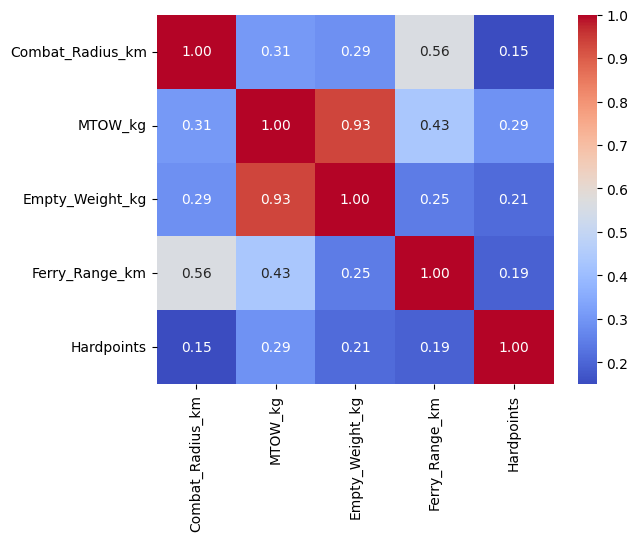

In [73]:
# Correlations
selected = fad[
[
"Combat_Radius_km",
"MTOW_kg",
"Empty_Weight_kg",
"Ferry_Range_km",
"Hardpoints"
]
]

corr = selected.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

**EDA Observations**

**Combat Radius x MTOW**
- The scatter plot reveals a moderate positive relationship between combat radius and the maximum take-off weight (MTOW), around **30%**. Usually, heavier aircraft tends to have a greater operational range, but the relationship is not strong enough to conclude if MTOW alone is a reliable predictor.

**Combat Radius x Empty Weight**
- Empty Weight exhibits a similar behavior to MTOW, with a moderate positive relationship, around **28%**. This is expected because Empty Weight and MTOW are naturally related. Larger aircraft possess both higher MTOW and Empty Weight.

**Combat Radius x Ferry Range**
- Among the analyzed variables, Ferry Range presents the strongest positive relationship with Combat Radius, around **56%**. aircraft capable of travelling higher distances without combat load also tend to have a greater operational combat radius. Appears to be one of the most informative predictors for the target variable.

**Combat Radius x Hardpoints**
- The number of hardpoints shows a weak positive relationship with combat radius, around **14%**. This suggests that aicrafts carrying capacity has a little direct influence on its operational range.

**Combat Radius by Aircraft Role**
- The relationship between combat radius and aircraft roles indicated that usually, *interceptors* have higher average combat radius. However, **these results should be interpreted with caution**, as the dataset contains a limited number of observations for each role. **Results taken of this relationship will not be considered for further actions.**

**Observations**
- These findings suggest that the aircraft combat radius is influenced by multiple aircraft characteristics.

**Machine Learning**

In [74]:
# Data Preprocessing

# Target Variable
target = 'Combat_Radius_km'

# Identifier columns that shouldtrain-test splitmodel features
identifier_cols = [train-test spliteature Matrix and Target Vector
X = fad.drop(columns=[target] + identifier_cols)
y = fad[targtrain-test splitt Split
x_train, x_test, y_train, y_test = train_test_split(X,
                                                    train-test split                                               test_size=0.2,
                                                        random_state=42)
# Due to relatively small dataset (47 aircraft), the model evaluation is based on a single train-test split.

In [75]:
# Identify numerical and categorical features
numeric_features = x_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = x_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numerical Features:')
print(numeric_features)

print('\nCategorical Features:')
print(categorical_features)

# Using x_train instead of X because preprocessing must be learned only with train data, also helping to avoid data leakage.

Numerical Features:
['First_Flight', 'In_Service', 'Max_Speed_kmh', 'Supercruise_kmh', 'Service_Ceiling_m', 'Ferry_Range_km', 'Empty_Weight_kg', 'MTOW_kg', 'Hardpoints', 'Max_Weapon_Load_kg', 'RCS_m2', 'Engine_Count', 'Thrust_per_Engine_kN', 'Units_Produced', 'Unit_Cost_M_USD', 'Internal_Fuel_kg', 'Fuel_Consumption_Cruise_kg_h', 'Number_of_Operators', 'Cruise_Speed_kmh', 'Cost_per_Flight_Hour_USD', 'Radar_Score', 'Missile_Score', 'EW_Score', 'Combat_Kills', 'Combat_Losses_AirToAir', 'Kill_Loss_Ratio', 'Combat_Kills_A2A', 'Combat_Losses_A2A', 'Kill_Ratio', 'Combat_Sorties_Estimated']

Categorical Features:
['Manufacturer', 'Country', 'Generation', 'Role', 'Radar_Type', 'Radar_Model', 'Engine_Model', 'Supercruise_Capable', 'Thrust_Vectoring', 'Internal_Weapons_Bay', 'Status', 'Combat_Record_Status', 'Combat_Status']


In [76]:
# Preprocessor Without Scaling (PWS)

# Numerical preprocessing without scaling
numeric_transformer_pws = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Full Preprocessing without scaling
preprocessor_pws = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_pws, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Will be used in models that does not need scaling, like decision tree, random forest and xgboost.
# For numerical values, in NaN, we apply median
# For categorical variables, most frequent is applied

In [77]:
# Preprocessor with Scaling

# Numerical Preprocessing with scaling
numeric_transformer_with_scaling = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Full Preprocessing with scaling
preprocessor_with_scaling = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_with_scaling, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Will be used in models that needs or have a better performance with scale, like KNN and Linear Regression

**Preprocessing Setup**

- The dataset contains both numerical and categorical features, so separate preprocessing strategies were created for each data type.

- Numerical features are handled with median imputation. This strategy is robust to outliers and prevents missing values from causing model errors.

- Categorical features are handled with most-frequent imputation and One-Hot Encoding. One-Hot Encoding is used because these categorical variables do not have a natural numeric order.

- Two preprocessing pipelines were created. The first one does not apply scaling and will be used for tree-based models such as Decision Tree, Random Forest, and XGBoost. The second one applies StandardScaler to numerical variables and will be used for scale-sensitive models such as KNN and Linear Regression.

- The preprocessors will later be placed inside model pipelines, ensuring that all transformations are fitted only on the training data and then applied to the test data. This helps prevent data leakage.

In [78]:
# Model Training
def train_test_model(model,
                     x_train, y_train,
                     x_test, y_test,
                     model_name):
  # Training Time
  train_start = time.time()
  model.fit(x_train, y_train)
  train_time = time.time() - train_start # in seconds

  # Predictions
  pred_train = model.predict(x_train) # model performance in training and test

  start_pred = time.time()
  pred_test = model.predict(x_test)
  time_pred_test = time.time() - start_pred # in seconds

  # Train Metrics
  r2_train = r2_score(y_train, pred_train)
  mae_train = mean_absolute_error(y_train, pred_train)
  mape_train = mean_absolute_percentage_error(y_train, pred_train)
  rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))

  # Test Metrics
  r2_test = r2_score(y_test, pred_test)
  mae_test = mean_absolute_error(y_test, pred_test)
  mape_test = mean_absolute_percentage_error(y_test, pred_test)
  rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

  # Results Table
  results = [model_name, r2_train, r2_test,
             mae_train, mae_test, mape_train,
             mape_test, rmse_train, rmse_test,
             time_pred_test, train_time
             ]
# defining columns name
  results = pd.DataFrame(results).T # lines in columns
  results.columns = ['Model', 'R2 Train', 'R2 Test',
                     'MAE Train', 'MAE Test', 'MAPE Train',
                     'MAPE Test', 'RMSE Train', 'RMSE Test',
                     'Predict Time', 'Training Time'
                     ]
  return results

**Starting Models Training**

In [79]:
## KNN - K-Nearest Neighbors
knn = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', KNeighborsRegressor())
])

Results = train_test_model(knn,
                           x_train,
                           y_train,
                           x_test,
                           y_test,
                           'KNN'
                           )
Results

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739


**KNN Notes:**
- The KNN model achieved a test MAE of approximately **360 km** and a test RMSE of approximately **540 km**. It suggest that some aircraft predictions contain larger errors.
- The test MAPE was approximately **24%**, meaning that the model's average percentage error was around one quarter of the actual combat radius values.
- The KNN explained only a small portion of the variation in combat radius. This is likely related to the small dataset size and high-dimensional feature space.

In [80]:
## SVR - Support Vector Machine (Regression)
svr = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', SVR())
])

Results_SVR = train_test_model(svr,
                           x_train,
                           y_train,
                           x_test,
                           y_test,
                           'SVR'
                           )
Results = pd.concat([Results, Results_SVR], ignore_index=True)
# Explicitly remove any 'SVR' entries and then drop duplicates, keeping the latest 'SVR'
Results = Results[Results['Model'] != 'SVM']
Results = Results.drop_duplicates(subset=['Model'], keep='last')
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.008824,0.018357


**SVR Notes:**
- The SVR model achieved a test MAE of approximately 450 km and a test RMSE of approximately 591 km. Contain larger error.
- The test MAPE was approximately 38%.
- The KNN model performed better than the SVR.

In [81]:
## Decision Tree Regressor
dt = Pipeline(steps=[
    ('preprocessor', preprocessor_pws),
    ('model', DecisionTreeRegressor(random_state=42))
])
Results_DT = train_test_model(dt,
                              x_train,
                              y_train,
                              x_test,
                              y_test,
                              'Decision Tree'
                              )
Results = pd.concat([Results, Results_DT])
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.008824,0.018357
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.008085,0.02317


**Decision Tree Notes:**
- Achieved a test MAE of approximately 557 km and a test RMSE of approximately 719 km. Still contain larger error.
- Test MAPE was approximately 56%.
- Overfitting may have happened due to the results of the  results.

In [82]:
## Random Forest Regressor
rf = Pipeline(steps=[
    ('preprocessor', preprocessor_pws),
    ('model', RandomForestRegressor(random_state=42))
])
Results_RF = train_test_model(rf,
                              x_train,
                              y_train,
                              x_test,
                              y_test,
                              'Random Forest'
                              )
Results = pd.concat([Results, Results_RF])
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.018538,0.260084
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.008824,0.018357
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.008085,0.02317


**Random Forest Regressor Notes:**
- Achieved a test MAE of approximately 356 km and a test RMSE of approximately 483 km. Still contain error but decreased significantly on the random forest model.
- The test MAPE was approximately 29%
- The Random Forest had a much better performance than other models, achieving approximately 0.3 on the R2 test.

In [83]:
## XGBoost - Extreme Gradient Boosting
xgb = Pipeline(steps=[
    ('preprocessor', preprocessor_pws),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42
    ))
])

Results_XGB = train_test_model(xgb,
                               x_train,
                               y_train,
                               x_test,
                               y_test,
                               'XGBoost'
                               )
Results = pd.concat([Results, Results_XGB])
Results.sort_values(by='RMSE Test')


,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.018538,0.260084
0,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009529,0.087913
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.008824,0.018357
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.008085,0.02317


**XGBoost Notes:**
- Achieved a test MAE of approximately 368 km and a test RMSE of approximately 497 km. Contain error, performing better than other models, except of Random Forest.
- Test MAPE was approximately 33%
- Achieved a better performance in the difference between RMSE Test and MAE Test.

In [84]:
# Multiple Linear Regression
mlr = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', LinearRegression())
])

Results_MLR = train_test_model(mlr,
                               x_train,
                               y_train,
                               x_test,
                               y_test,
                               'Multiple Linear Regression'
                               )

Results = pd.concat([Results, Results_MLR])
Results = Results.drop_duplicates(subset=['Model'])
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.018538,0.260084
0,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009529,0.087913
0,Multiple Linear Regression,1.0,0.16493,0.005545,395.496405,0.000007,0.326524,0.007284,526.979275,0.008551,0.023754
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.008824,0.018357
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.008085,0.02317


**Linear Multiple Regression Notes:**
- Achieved a test MAE of approximately 395 km and a test RMSE of approximately 526 km. Contain large error.
- Test MAPE was approximately 32%.
- Some results suggests that overfitting happened.

In [85]:
# Lasso
ls = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', Lasso())
])

Results_LS = train_test_model(ls,
                              x_train,
                              y_train,
                              x_test,
                              y_test,
                              'Lasso'
                              )
Results = pd.concat([Results, Results_LS])
Results.sort_values(by='RMSE Test')

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:656: ConvergenceWarning:

Objective did not converge. You might want to increase the number of iterations. Duality gap: 10157.627542318238, tolerance: 860.3853368421054



,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.018538,0.260084
0,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009529,0.087913
0,Multiple Linear Regression,1.0,0.16493,0.005545,395.496405,0.000007,0.326524,0.007284,526.979275,0.008551,0.023754
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.008824,0.018357
0,Lasso,0.997035,-0.27946,20.226155,509.584807,0.023714,0.45364,25.910022,652.297285,0.007785,0.037571
0,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.008085,0.02317


**Lasso Notes:**
- Achieved a test MAE of approximately 509 km and a test RMSE of 652 km. Contain error, however, has better difference numbers than other models with higher RMSE Test.
- Test MAPE was approximately 45%.
- Had a bad overall performance.

In [86]:
# Ridge
rd = Pipeline(steps=[
    ('preprocessor', preprocessor_with_scaling),
    ('model', Ridge(
        alpha=1000
    ))
])

Results_RD = train_test_model(rd,
                              x_train,
                              y_train,
                              x_test,
                              y_test,
                              'Ridge'
                              )
Results = pd.concat([Results, Results_RD], ignore_index=True)
Results = Results.drop_duplicates(subset=['Model'])
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
3,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.018538,0.260084
4,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009529,0.087913
5,Multiple Linear Regression,1.0,0.16493,0.005545,395.496405,0.000007,0.326524,0.007284,526.979275,0.008551,0.023754
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739
7,Ridge,0.111589,-0.002164,396.348355,433.839217,0.487391,0.368388,448.499244,577.299862,0.009013,0.024061
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.008824,0.018357
6,Lasso,0.997035,-0.27946,20.226155,509.584807,0.023714,0.45364,25.910022,652.297285,0.007785,0.037571
2,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.008085,0.02317


In [87]:
Results.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
3,Random Forest,0.908267,0.29586,125.006842,356.225,0.148351,0.295605,144.117856,483.906661,0.018538,0.260084
4,XGBoost,1.0,0.256702,0.00039,368.072845,0.0,0.333094,0.000519,497.180016,0.009529,0.087913
5,Multiple Linear Regression,1.0,0.16493,0.005545,395.496405,0.000007,0.326524,0.007284,526.979275,0.008551,0.023754
0,KNN,0.36117,0.124298,310.768421,359.62,0.365828,0.241252,380.318285,539.647748,0.0094,0.018739
7,Ridge,0.111589,-0.002164,396.348355,433.839217,0.487391,0.368388,448.499244,577.299862,0.009013,0.024061
1,SVR,0.003186,-0.051993,411.06001,449.086257,0.507983,0.380966,475.074516,591.478069,0.008824,0.018357
6,Lasso,0.997035,-0.27946,20.226155,509.584807,0.023714,0.45364,25.910022,652.297285,0.007785,0.037571
2,Decision Tree,1.0,-0.555144,0.0,557.0,0.0,0.561978,0.0,719.146578,0.008085,0.02317


**Ridge Notes:**
- Achieved a test MAE of approximately 433 km and a test RMSE of approximately 577 km. Contain errors.
- Test MAPE of approximately 36%.
- Had a bad performance.

### Model Performance Comparison and Best Model Selection
- Based on the test RMSE, Random Forest achieved the best overall performance among the evaluated models. Since RMSE was selected as the main metric, this model is considered the strongest candidate in the 1.0 pipeline.

- Random Forest obtained the lowest RMSE Test, indicating that it produced the smallest penalized prediction error in kilometers. It also achieved the highest R² Test among the tested models, suggesting that it explained more variation in Combat_Radius_km than the alternatives.

- Some models, such as Decision Tree, XGBoost, and Lasso, showed signs of overfitting due to very high training performance combined with weaker test performance. This is expected in small datasets and reinforces the need to compare models using test metrics rather than training metrics.

### Final Conclusion

- The 1.0 machine learning pipeline successfully evaluated multiple regression models to predict aircraft Combat_Radius_km using technical and engineering specifications.

- Random Forest was selected as the best-performing model based on test RMSE, the main evaluation metric for this project. It achieved the lowest RMSE among the tested models and the highest R² score on the test set.

- Although the model showed the ability to capture useful patterns, its performance remained moderate. The results suggest that combat radius is influenced by complex engineering, aerodynamic, mission-profile, and fuel-efficiency factors that may not be fully represented in the available dataset.

- This 1.0 pipeline provides a strong foundation for future improvements, including additional data collection, feature engineering, hyperparameter tuning, cross-validation, and deeper model interpretation.

# **MAPP v1.1 - Validation, Baselines and Feature Set Improvement**

- Version 1.1 improves the reliability of the MAPP v1.0 modeling process.

- The main goal is not to replace the previous version, but to evaluate the models more carefully using baseline models, cross-validation, and feature set comparison.

- Since the dataset contains only 48 aircraft, a single train-test split may produce unstable results. For this reason, version 1.1 introduces a more robust evaluation workflow.

- MAPP v1.1 will test groups of variables, like engineering and operational features.

In [88]:
# MAPP v1.1 - Independent Setup
target_v11 = 'Combat_Radius_km'
identifier_cols_v11 = ['Aircraft']

X_v11 = fad.drop(columns=[target_v11] + identifier_cols_v11)
y_v11 = fad[target_v11]

print('X_v11 shape:', X_v11.shape)
print('y_v11 shape:', y_v11.shape)

print(type(X_v11))
print(type(y_v11))

X_v11 shape: (48, 43)
y_v11 shape: (48,)
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


**Limitations of Version 1.0**

- MAPP v1.0 provided the first machine learning pipeline for predicting combat radius and selected the best model based on test RMSE. However, some limitations were identified:

- Due to a relative small dataset, using a single train-test split makes the model evaluation sensitive.
- Some features may be redundant or highly correlated.
- More robust validation is needed before confirming the best model.

For these reasons, MAPP v1.1 focuses on improving the evaluation process through baseline models, cross-validation and feature set comparison.

In [89]:
# MAPP v1.1 - Baseline Setup

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Train-test split used only for initial baseline comparison
x_train_v11, x_test_v11, y_train_v11, y_test_v11 = train_test_split(
    X_v11,
    y_v11,
    test_size=0.2,
    random_state=42
)

baseline_models_v11 = {
    'Mean Baseline': DummyRegressor(strategy='mean'),
    'Median Baseline': DummyRegressor(strategy='median')
}

print('Training set shape:', x_train_v11.shape)
print('Test set shape:', x_test_v11.shape)
print('Baseline models created:', list(baseline_models_v11.keys()))

Training set shape: (38, 43)
Test set shape: (10, 43)
Baseline models created: ['Mean Baseline', 'Median Baseline']


In [90]:
def evaluate_baseline_v11(model_v11, x_train_v11, x_test_v11, y_train_v11, y_test_v11, model_name_v11):
  # Training time
  train_start_v11 = time.time()
  model_v11.fit(x_train_v11, y_train_v11)
  train_time_v11 = time.time() - train_start_v11

  # Predictions
  pred_train_v11 = model_v11.predict(x_train_v11)

  start_pred_v11 = time.time()
  pred_test_v11 = model_v11.predict(x_test_v11)
  time_pred_test_v11 = time.time() - start_pred_v11

  # Train Metrics
  r2_train_v11 = r2_score(y_train_v11, pred_train_v11)
  mae_train_v11 = mean_absolute_error(y_train_v11, pred_train_v11)
  mape_train_v11 = mean_absolute_percentage_error(y_train_v11, pred_train_v11)
  rmse_train_v11 = np.sqrt(mean_squared_error(y_train_v11, pred_train_v11)
  )
  # Test Metrics
  r2_test_v11 = r2_score(y_test_v11, pred_test_v11)
  mae_test_v11 = mean_absolute_error(y_test_v11, pred_test_v11)
  mape_test_v11 = mean_absolute_percentage_error(y_test_v11, pred_test_v11)
  rmse_test_v11 = np.sqrt(mean_squared_error(y_test_v11, pred_test_v11)
  )
  # Results Table
  results_v11 = [model_name_v11, r2_train_v11, r2_test_v11,
                 mae_train_v11, mae_test_v11, mape_train_v11,
                 mape_test_v11, rmse_train_v11, rmse_test_v11,
                 time_pred_test_v11, train_time_v11
                 ]
  # Columns Names
  results_v11 = pd.DataFrame(results_v11).T
  results_v11.columns = ['Model', 'R2 Train', 'R2 Test',
                        'MAE Train', 'MAE Test', 'MAPE Train',
                        'MAPE Test', 'RMSE Train', 'RMSE Test',
                        'Predict Time', 'Training Time'
                        ]
  return results_v11

In [91]:
# Baseline Evaluation

baseline_results_v11 = pd.DataFrame()

for model_name_v11, model_v11 in baseline_models_v11.items():
  print('Evaluating', model_name_v11)

  results_v11 = evaluate_baseline_v11(
      model_v11,
      x_train_v11,
      x_test_v11,
      y_train_v11,
      y_test_v11,
      model_name_v11
  )

  baseline_results_v11 = pd.concat(
      [baseline_results_v11, results_v11],
      ignore_index=True
  )

baseline_results_v11.sort_values(by='RMSE Test')

Evaluating Mean Baseline
Evaluating Median Baseline


,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
0,Mean Baseline,0.0,-0.045171,412.354571,449.5,0.514334,0.385046,475.833158,589.556899,0.000058,0.000666
1,Median Baseline,-0.000509,-0.053431,412.0,449.5,0.508991,0.381287,475.954277,591.882167,0.000057,0.000528


**Ferry Range Linear Baseline**
- The previous baselines used only the mean and median of the target variable.
- This step creates a stronger baseline using 'Ferry_Range_km', which showed the highest correlation in the EDA.
- Using only this feature, a simple linear regression model will be trained.

In [92]:
# Ferry Range Linear Baseline
ferry_feature_v11 = ['Ferry_Range_km']

x_train_ferry_v11 = x_train_v11[ferry_feature_v11]
x_test_ferry_v11 = x_test_v11[ferry_feature_v11]

ferry_linear_model_v11 = LinearRegression()

ferry_results_v11 = evaluate_baseline_v11(
    ferry_linear_model_v11,
    x_train_ferry_v11,
    x_test_ferry_v11,
    y_train_v11,
    y_test_v11,
    'Ferry Range Linear Baseline'
)

baseline_results_v11 = pd.concat(
    [baseline_results_v11, ferry_results_v11],
    ignore_index=True
)

baseline_results_v11.sort_values(by='RMSE Test')

,Model,R2 Train,R2 Test,MAE Train,MAE Test,MAPE Train,MAPE Test,RMSE Train,RMSE Test,Predict Time,Training Time
2,Ferry Range Linear Baseline,0.268526,0.393782,356.169871,341.22139,0.418267,0.309407,406.962221,449.000365,0.00084,0.001964
0,Mean Baseline,0.0,-0.045171,412.354571,449.5,0.514334,0.385046,475.833158,589.556899,0.000058,0.000666
1,Median Baseline,-0.000509,-0.053431,412.0,449.5,0.508991,0.381287,475.954277,591.882167,0.000057,0.000528


  **Baseline Evaluations Observations**
  The Ferry Range Linear Baseline performed significantly better than the mean and median baselines.
  - Using only 'Ferry_Range_km', the linear baseline achieved a lower RMSE Test than the simple target-based baselines.
  - Suggests that ferry range has the strongest correlation with the combat radius.
  - The evaluation is still based on a single train-test split.

**Feature Set Design**
- MAPP v1.1 will have features separated into groups to evaluate how different variables affect model performance.
- MAPP v1.1 will test how models performs using only engineering features of the aircraft and other features.


In [93]:
# Feature Set Design

# Engineering
engineering_features_v11 = [
    'Max_Speed_kmh',
    'Supercruise_kmh',
    'Service_Ceiling_m',
    'Ferry_Range_km',
    'Empty_Weight_kg',
    'MTOW_kg',
    'Hardpoints',
    'Max_Weapon_Load_kg',
    'Engine_Count',
    'Thrust_per_Engine_kN',
    'Internal_Fuel_kg',
    'Fuel_Consumption_Cruise_kg_h',
    'Cruise_Speed_kmh'
]

# Operational
operational_features_v11 = [
    'Units_Produced',
    'Unit_Cost_M_USD',
    'Number_of_Operators',
    'Cost_per_Flight_Hour_USD',
    'Status'
]

engineering_operational_features_v11 = engineering_features_v11 + operational_features_v11

all_features_v11 = X_v11.columns.tolist()

feature_sets_v11 = {
    'Engineering Only': engineering_features_v11,
    'Engineering + Operational': engineering_operational_features_v11,
    'All Features': all_features_v11
}

for feature_set_name_v11, feature_list_v11 in feature_sets_v11.items():
  print(feature_set_name_v11, ':', len(feature_list_v11), 'features')

Engineering Only : 13 features
Engineering + Operational : 18 features
All Features : 43 features


**The feature sets contain both numerical and categorical variables.**

To make the data usable by machine learning models, version 1.1 uses preprocessing pipelines:

- Numerical variables are handled with median imputation.
- Categorical variables are handled with most-frequent imputation and One-Hot Encoding.
- Scaling is optional and will be used only for models that are sensitive to feature scale, such as KNN, SVR, and linear models.

The preprocessing function is created independently for version 1.1 and does not reuse preprocessing variables from version 1.0.

In [94]:
# Preprocessing Strategy
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

def create_preprocessor_v11(X_data_v11, selected_features_v11, scaling_v11=False):
  X_selected_v11 = X_data_v11[selected_features_v11]

  numerics_features_v11 = X_selected_v11.select_dtypes(
      include=['int64', 'float64']
  ).columns.tolist()

  categorical_features_v11 = X_selected_v11.select_dtypes(
      include=['object', 'category', 'bool']
  ).columns.tolist()

  if scaling_v11:
    numeric_transformer_v11 = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
  else:
    numeric_transformer_v11 = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])

  categorical_transformer_v11 = Pipeline(steps=[
      ('imputer', SimpleImputer(strategy='most_frequent')),
      ('onehot', OneHotEncoder(handle_unknown='ignore'))
  ])

  preprocessor_v11 = ColumnTransformer(
      transformers=[
          ('num', numeric_transformer_v11, numerics_features_v11),
          ('cat', categorical_transformer_v11, categorical_features_v11)
      ]
  )

  return preprocessor_v11

**Cross-Validation Evaluation Function**

MAPP v1.1 introduces cross-validation to make model evaluation more reliable. Instead of relying on a single train-test split, cross-validation evaluates each model across multiple train-test partition. It is important due to a relative small dataset.

In [95]:
# Cross-Validation Evaluation Function

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate

def evaluate_model_cv_v11(
    model_v11,
    X_data_v11,
    y_data_v11,
    selected_features_v11,
    feature_set_name_v11,
    model_name_v11,
    scaling_v11=False
):
    X_selected_v11 = X_data_v11[selected_features_v11]

    preprocessor_v11 = create_preprocessor_v11(
        X_data_v11,
        selected_features_v11,
        scaling_v11=scaling_v11
    )

    pipeline_v11 = Pipeline(steps=[
        ('preprocessor', preprocessor_v11),
        ('model', model_v11)
    ])

    cv_v11 = KFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scoring_v11 = {
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }

    cv_results_v11 = cross_validate(
        pipeline_v11,
        X_selected_v11,
        y_data_v11,
        cv=cv_v11,
        scoring=scoring_v11,
        return_train_score=True
    )

    results_v11 = pd.DataFrame({
        'Model': [model_name_v11],
        'Feature Set': [feature_set_name_v11],
        'R2 CV Mean': [cv_results_v11['test_r2'].mean()],
        'R2 CV Std': [cv_results_v11['test_r2'].std()],
        'MAE CV Mean': [-cv_results_v11['test_mae'].mean()],
        'MAE CV Std': [cv_results_v11['test_mae'].std()],
        'RMSE CV Mean': [-cv_results_v11['test_rmse'].mean()],
        'RMSE CV Std': [cv_results_v11['test_rmse'].std()],
        'Train R2 CV Mean': [cv_results_v11['train_r2'].mean()],
        'Train RMSE CV Mean': [-cv_results_v11['train_rmse'].mean()]
    })

    return results_v11

**Model Re-Evaluation with Cross-Validation**

The main regression models from version 1.0 are re-evaluated using cross-validation.

Each model is tested across the feature sets created in version 1.1:

- Engineering Only
- Engineering + Operational
- All Features

**This allows the project to compare not only different models, but also different groups of predictors.**

Models that are sensitive to feature scale use numerical scaling. Tree-based models are evaluated without scaling.

In [50]:
# MAPP v1.1 - Model Re-Evaluation with Cross-Validation
models_v11 = {
    'Linear_Regression': {
        'model': LinearRegression(),
        'scaling': True
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'scaling': True
    },
    'SVR': {
        'model': SVR(),
        'scaling': True
    },
    'Decision_Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'scaling': False
    },
    'Random_Forest': {
        'model': RandomForestRegressor(random_state=42),
        'scaling': False
    },
    'XGBoost': {
        'model': XGBRegressor(
            objective='reg:squarederror',
            random_state=42
        ),
        'scaling': False
    },
    'Ridge': {
        'model': Ridge(alpha=1000),
        'scaling': True
    },
    'Lasso': {
        'model': Lasso(max_iter=10000),
        'scaling': True
    }
}

cv_model_results_v11 = pd.DataFrame()

for feature_set_name_v11, feature_list_v11 in feature_sets_v11.items():
  print('Feature Set:', feature_set_name_v11)

  for model_name_v11, model_info_v11 in models_v11.items():
    print('Evaluating:', model_name_v11)

    results_v11 = evaluate_model_cv_v11(
        model_info_v11['model'],
        X_v11,
        y_v11,
        feature_list_v11,
        feature_set_name_v11,
        model_name_v11,
        scaling_v11=model_info_v11['scaling']
    )

    cv_model_results_v11 = pd.concat(
        [cv_model_results_v11, results_v11],
        ignore_index=True
    )

cv_model_results_v11.sort_values(by='RMSE CV Mean')

Feature Set: Engineering Only
Evaluating: Linear_Regression
Evaluating: KNN
Evaluating: SVR
Evaluating: Decision_Tree
Evaluating: Random_Forest
Evaluating: XGBoost
Evaluating: Ridge
Evaluating: Lasso
Feature Set: Engineering + Operational
Evaluating: Linear_Regression
Evaluating: KNN
Evaluating: SVR
Evaluating: Decision_Tree
Evaluating: Random_Forest
Evaluating: XGBoost
Evaluating: Ridge
Evaluating: Lasso
Feature Set: All Features
Evaluating: Linear_Regression
Evaluating: KNN
Evaluating: SVR
Evaluating: Decision_Tree
Evaluating: Random_Forest
Evaluating: XGBoost
Evaluating: Ridge
Evaluating: Lasso


,Model,Feature Set,R2 CV Mean,R2 CV Std,MAE CV Mean,MAE CV Std,RMSE CV Mean,RMSE CV Std,Train R2 CV Mean,Train RMSE CV Mean
5,XGBoost,Engineering Only,0.356348,0.261776,275.532477,67.309800,364.693372,73.663520,1.000000,0.000748
13,XGBoost,Engineering + Operational,0.342250,0.221599,283.941049,73.774253,377.036865,89.287107,1.000000,0.000634
4,Random_Forest,Engineering Only,0.329556,0.184159,314.424889,39.088459,379.776213,67.470641,0.913464,146.716639
12,Random_Forest,Engineering + Operational,0.282357,0.191292,328.196756,31.311566,392.782353,65.407175,0.906258,152.614716
21,XGBoost,All Features,0.191775,0.358422,329.806134,59.497366,405.883899,90.616462,1.000000,0.000517
20,Random_Forest,All Features,0.218803,0.178100,341.930911,48.375571,413.206287,68.685468,0.906597,151.983746
3,Decision_Tree,Engineering Only,0.040983,0.401267,331.071111,54.106981,437.819217,61.736929,1.000000,-0.000000
1,KNN,Engineering Only,0.030570,0.269766,379.172889,72.105534,455.968624,68.146878,0.422091,378.688104
9,KNN,Engineering + Operational,-0.007554,0.253888,391.820889,68.271357,467.423578,65.537124,0.382475,390.737341
7,Lasso,Engineering Only,-0.323060,0.980046,421.592474,79.046906,477.722562,98.087442,0.631593,301.351035


**Observations**

Cross-validation provided more reliable results showed, in general, better results than with a single train-test split.
- The best feature set is engineering only, followed by engineering + operational.
- All features set is the worst feature set

**Final Results Comparison**

Cross-validation results are now organized to identify the strongest model and feature.

The final comparison also considers:
- Test performance under cross-validation.
- Difference between training and validation performance.
- Feature set behavior.
- Comparison against baseline models.

In [96]:
# Final Results Comparison
final_cv_results_v11 = cv_model_results_v11.sort_values(
    by='RMSE CV Mean'
).reset_index(drop=True)

final_cv_results_v11.head(10)

,Model,Feature Set,R2 CV Mean,R2 CV Std,MAE CV Mean,MAE CV Std,RMSE CV Mean,RMSE CV Std,Train R2 CV Mean,Train RMSE CV Mean
0,XGBoost,Engineering Only,0.356348,0.261776,275.532477,67.309800,364.693372,73.663520,1.000000,0.000748
1,XGBoost,Engineering + Operational,0.342250,0.221599,283.941049,73.774253,377.036865,89.287107,1.000000,0.000634
2,Random_Forest,Engineering Only,0.329556,0.184159,314.424889,39.088459,379.776213,67.470641,0.913464,146.716639
3,Random_Forest,Engineering + Operational,0.282357,0.191292,328.196756,31.311566,392.782353,65.407175,0.906258,152.614716
4,XGBoost,All Features,0.191775,0.358422,329.806134,59.497366,405.883899,90.616462,1.000000,0.000517
5,Random_Forest,All Features,0.218803,0.178100,341.930911,48.375571,413.206287,68.685468,0.906597,151.983746
6,Decision_Tree,Engineering Only,0.040983,0.401267,331.071111,54.106981,437.819217,61.736929,1.000000,-0.000000
7,KNN,Engineering Only,0.030570,0.269766,379.172889,72.105534,455.968624,68.146878,0.422091,378.688104
8,KNN,Engineering + Operational,-0.007554,0.253888,391.820889,68.271357,467.423578,65.537124,0.382475,390.737341
9,Lasso,Engineering Only,-0.323060,0.980046,421.592474,79.046906,477.722562,98.087442,0.631593,301.351035


In [97]:
# Best Model and Feature Set Combination

best_result_v11 = final_cv_results_v11.iloc[0] # get best model

print('Best Model:', best_result_v11['Model'])
print('Best Feature Set:', best_result_v11['Feature Set'])
print('RMSE CV Mean:', best_result_v11['RMSE CV Mean'])
print('MAE CV Mean:', best_result_v11['MAE CV Mean'])
print('R2 CV Mean:', best_result_v11['R2 CV Mean'])
print('Train R2 CV Mean:', best_result_v11['Train R2 CV Mean'])
print('Train RMSE CV Mean:', best_result_v11['Train RMSE CV Mean'])

Best Model: XGBoost
Best Feature Set: Engineering Only
RMSE CV Mean: 364.69337158203126
MAE CV Mean: 275.5324768066406
R2 CV Mean: 0.35634808540344237
Train R2 CV Mean: 1.0
Train RMSE CV Mean: 0.0007484599482268095


## 12. Version 1.1 Conclusion

Version 1.1 improved the original MAPP v1.0 workflow by introducing baseline models, feature set comparison, and cross-validation.

The baseline evaluation showed that simple target-based predictors, such as the mean and median baselines, produced relatively high errors. The Ferry Range Linear Baseline performed much better, confirming that `Ferry_Range_km` is an important predictor of `Combat_Radius_km`.

The cross-validation evaluation showed that models using the **Engineering Only** feature set generally performed better than models using all available features. This suggests that technical aircraft specifications are more useful for predicting combat radius than adding every available variable.

The best cross-validation result was achieved by **XGBoost with the Engineering Only feature set**, with an average RMSE of approximately **365 km** and an average MAE of approximately **276 km**.

However, XGBoost also showed signs of overfitting, with near-perfect training performance. For this reason, the result should be interpreted with caution. Random Forest also performed competitively and showed less extreme training behavior.

Compared to version 1.0, version 1.1 provides a more reliable evaluation process. The main conclusion is that model performance should not be judged only by a single train-test split. Baselines, feature set comparison, and cross-validation are necessary to better understand model behavior.

### Main Findings

- Baseline models are necessary to evaluate whether complex models add real predictive value.
- `Ferry_Range_km` is a strong individual predictor of `Combat_Radius_km`.
- The Engineering Only feature set produced the strongest results.
- Using all features did not improve performance and often made models less stable.
- XGBoost achieved the lowest cross-validation RMSE, but showed signs of overfitting.
- Random Forest remained a strong and more stable candidate model.

### Next Steps

Future versions of MAPP may focus on:

- Expanding the dataset with more aircraft and verified sources.
- Improving feature engineering with aviation-related derived variables.
- Testing feature selection methods.
- Applying light hyperparameter tuning.
- Comparing model stability across repeated validation strategies.